In [65]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
np.random.seed(42)

from sklearn.metrics import adjusted_rand_score

In [72]:
from scipy.stats import mode

def get_mapped_accuracy(true_y, pred_y, k):
    # Create a mapping from pred_label -> true_label
    mapped_preds = np.zeros_like(pred_y)
    
    for c in range(k):
        # Find all indices where prediction is c
        mask = (pred_y == c)
        if np.sum(mask) > 0:
            # Find the most common true label in these indices
            # mode returns (mode_array, count_array)
            most_common_true_label = mode(true_y[mask], keepdims=True)[0][0]
            mapped_preds[mask] = most_common_true_label
            
    return accuracy_score(true_y, mapped_preds)

In [81]:
def kmeans(X:np.ndarray, k:int=5, iters:int=100, eval=False, plot=False, y:np.ndarray=None):

    # INITIALIZE
    # X shape = (n,m)
    # centroids shape = (5,m)
    rand_idx = np.random.choice(X.shape[0], k, replace=False)
    centroids = X[rand_idx]

    # LOOP    
    for i in range(iters):
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        pred_labels = np.argmin(distances, axis=1)
        new_centroids = np.array([X[pred_labels==c].mean(axis=0) for c in range(k)])

        # check for convergence
        if np.mean(np.abs(centroids-new_centroids)) <= 1e-3: break
        centroids = new_centroids

        if eval and y is not None:
            # accuracy = (pred_labels == y).sum() / y.shape[0]
            # accuracy = accuracy_score(y, pred_labels)
            # print(f"Accuracy at iteration {i}: {accuracy:.2%}")
            ari = adjusted_rand_score(y, pred_labels)
            accuracy = get_mapped_accuracy(y, pred_labels, k)
            print(f"iteration {i} | ARI: {ari:.2%} | accuracy: {accuracy:.2%}")
        
    if plot:
        plt.scatter(X[:,0], X[:,1], c=y)
        plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='x', s=200, linewidths=3)
        plt.show()

    return centroids, pred_labels

In [82]:
# import data
X,y = make_blobs(n_samples=10000, centers=5, n_features=2, random_state=42)
print(X.shape, y.shape)

# plot
# plt.scatter(X[:,0], X[:,1], c=y)
# plt.show()

(10000, 2) (10000,)


iteration 0 | ARI: 68.76% | accuracy: 79.34%
iteration 1 | ARI: 71.38% | accuracy: 79.96%
iteration 2 | ARI: 72.10% | accuracy: 79.96%
iteration 3 | ARI: 72.31% | accuracy: 79.96%
iteration 4 | ARI: 72.47% | accuracy: 79.96%
iteration 5 | ARI: 72.71% | accuracy: 79.96%
iteration 6 | ARI: 73.15% | accuracy: 79.96%
iteration 7 | ARI: 73.73% | accuracy: 79.96%
iteration 8 | ARI: 74.87% | accuracy: 80.80%
iteration 9 | ARI: 77.54% | accuracy: 85.41%
iteration 10 | ARI: 85.19% | accuracy: 92.65%
iteration 11 | ARI: 93.25% | accuracy: 97.09%
iteration 12 | ARI: 95.08% | accuracy: 97.93%
iteration 13 | ARI: 95.03% | accuracy: 97.91%
iteration 14 | ARI: 95.15% | accuracy: 97.96%


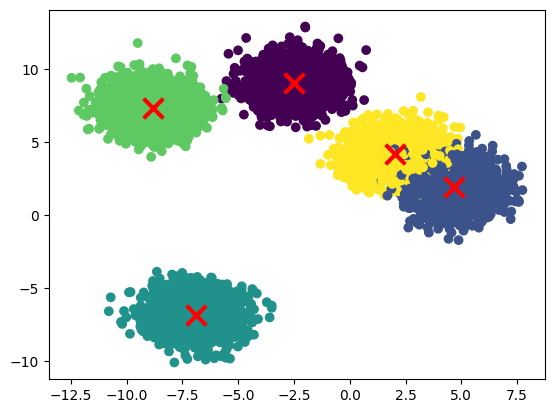

In [85]:
centroids, pred_labels = kmeans(X, k=5, iters=100, eval=True, plot=True, y=y)

In [15]:
k = 5

rand_idx = np.random.choice(X.shape[0], k, replace=False)
centroids = X[rand_idx]
centroids

array([[  5.57555723,   3.24472478],
       [-10.25669349,   5.5627141 ],
       [ -7.84660333,  -6.92782095],
       [ -9.62431722,   5.99228996],
       [  0.51757986,   4.92150752]])

In [16]:
X[:, np.newaxis].shape

(1000, 1, 2)

In [87]:
(X[:, np.newaxis] - centroids).shape

(10000, 5, 2)

In [21]:
distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
distances.shape

(1000, 5)